In [1]:
!pip install prophet


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error

np.random_state=42

plt.style.use("seaborn-v0_8")


Importing plotly failed. Interactive plots will not work.


In [3]:
#read the data

# Read the CSV
df = pd.read_csv('../data/gas_price_2526.csv')

# Parse date column and set index
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()

# Keep only the target column
df = df[["daily price"]]

print(df.head())
print(df.index.min(), "→", df.index.max())


            daily price
date                   
2025-01-19        39.85
2025-01-20        37.21
2025-01-21        37.33
2025-01-22        37.85
2025-01-23        35.70
2025-01-19 00:00:00 → 2026-06-02 00:00:00


C:\Users\sagal\AppData\Local\Temp\ipykernel_43452\2674796368.py:7: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"])


In [4]:
# Prepare data for Prophet

def prepare_prophet_data(df):
    prophet_df = df.copy()
    prophet_df = prophet_df.reset_index()
    prophet_df = prophet_df.rename(columns={"date": "ds", "daily price": "y"})
    return prophet_df

prophet_df = prepare_prophet_data(df)
prophet_df.head()


,ds,y
0,2025-01-19,39.85
1,2025-01-20,37.21
2,2025-01-21,37.33
3,2025-01-22,37.85
4,2025-01-23,35.70


In [5]:
#train and test split

def split_prophet_data(prophet_df, train_ratio=0.80):
    n = len(prophet_df)
    split_idx = int(n * train_ratio)

    train_df = prophet_df.iloc[:split_idx].copy()
    test_df  = prophet_df.iloc[split_idx:].copy()

    print(f"Total rows:   {n}")
    print(f"Train rows:   {len(train_df)}")
    print(f"Test rows:    {len(test_df)}")
    print(f"Train range:  {train_df['ds'].min().date()} → {train_df['ds'].max().date()}")
    print(f"Test range:   {test_df['ds'].min().date()} → {test_df['ds'].max().date()}")

    return train_df, test_df

train_df, test_df = split_prophet_data(prophet_df)


Total rows:   500
Train rows:   400
Test rows:    100
Train range:  2025-01-19 → 2026-02-22
Test range:   2026-02-23 → 2026-06-02


In [6]:
#build prophet model

def build_prophet_model():
    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False
    )
    return model

prophet_model = build_prophet_model()


In [7]:
#fit on training data

def fit_prophet(model, train_df):
    model.fit(train_df)
    print("Prophet model fitted on training data.")
    return model

prophet_model = fit_prophet(prophet_model, train_df)


12:40:09 - cmdstanpy - INFO - Chain [1] start processing
12:40:12 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted on training data.


In [8]:

def forecast_on_test(model, test_df):
    future = test_df[["ds"]].copy()
    forecast = model.predict(future)

    #relevant columns
    forecast = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]
    return forecast

test_forecast = forecast_on_test(prophet_model, test_df)
test_forecast.head()


,ds,yhat,yhat_lower,yhat_upper
0,2026-02-23,57.448700,53.159820,61.774796
1,2026-02-24,57.351330,53.120248,61.695693
2,2026-02-25,57.253961,53.034858,61.396715
3,2026-02-26,57.156591,52.768154,61.191010
4,2026-02-27,57.059221,53.065705,61.103467


In [9]:
#evaluate on test set

def evaluate_prophet(test_df, forecast_df):
    merged = test_df.merge(forecast_df, on="ds", how="inner")

    y_true = merged["y"].values
    y_pred = merged["yhat"].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.2f}%")

    return rmse, mae, mape

rmse, mae, mape = evaluate_prophet(test_df, test_forecast)


RMSE: 22.1884
MAE:  18.3465
MAPE: 23.85%


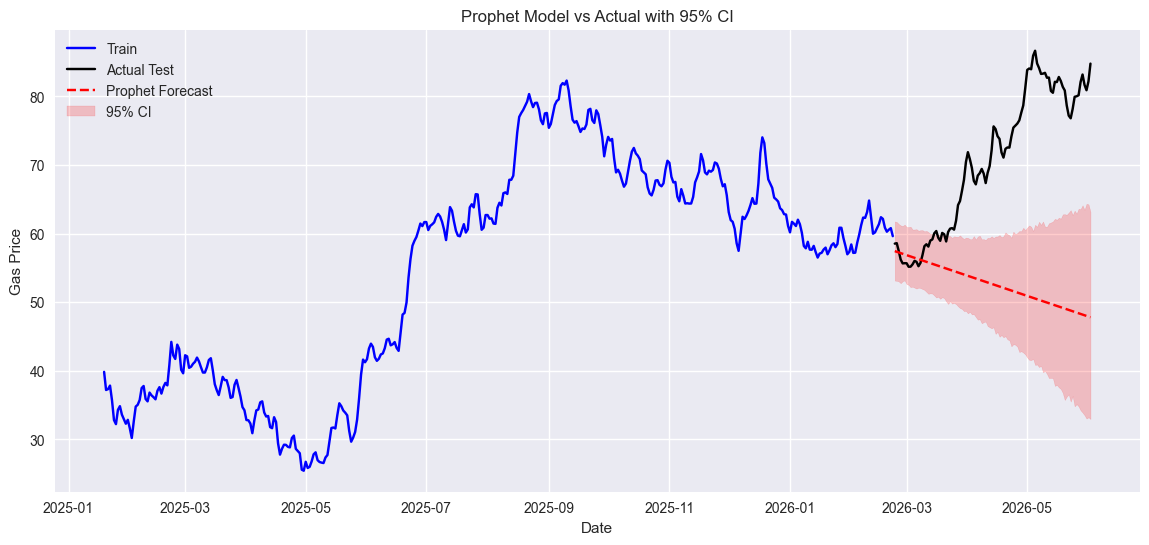

In [10]:
#plot results

def plot_prophet_results(train_df, test_df, forecast_df):
    merged = test_df.merge(forecast_df, on="ds", how="inner")

    plt.figure(figsize=(14,6))
    plt.plot(train_df["ds"], train_df["y"], label="Train", color="blue")
    plt.plot(test_df["ds"], test_df["y"], label="Actual Test", color="black")
    plt.plot(merged["ds"], merged["yhat"], label="Prophet Forecast", color="red", linestyle="--")
    
    plt.fill_between(
        merged["ds"],
        merged["yhat_lower"],
        merged["yhat_upper"],
        color="red",
        alpha=0.2,
        label="95% CI"
    )

    plt.title("Prophet Model vs Actual with 95% CI")
    plt.xlabel("Date")
    plt.ylabel("Gas Price")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_prophet_results(train_df, test_df, test_forecast)


In [11]:
#24 month forecast periods

def forecast_future(model, periods=730, freq="D"):
    future = model.make_future_dataframe(periods=periods, freq=freq)
    forecast = model.predict(future)
    forecast = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]
    return forecast

future_forecast = forecast_future(prophet_model, periods=730)
future_forecast.tail()


,ds,yhat,yhat_lower,yhat_upper
1125,2028-02-18,-13.144363,-319.872486,302.327367
1126,2028-02-19,-13.241733,-316.405408,303.337668
1127,2028-02-20,-13.339103,-319.493079,301.164169
1128,2028-02-21,-13.436473,-321.273509,303.943780
1129,2028-02-22,-13.533842,-322.431733,304.150601


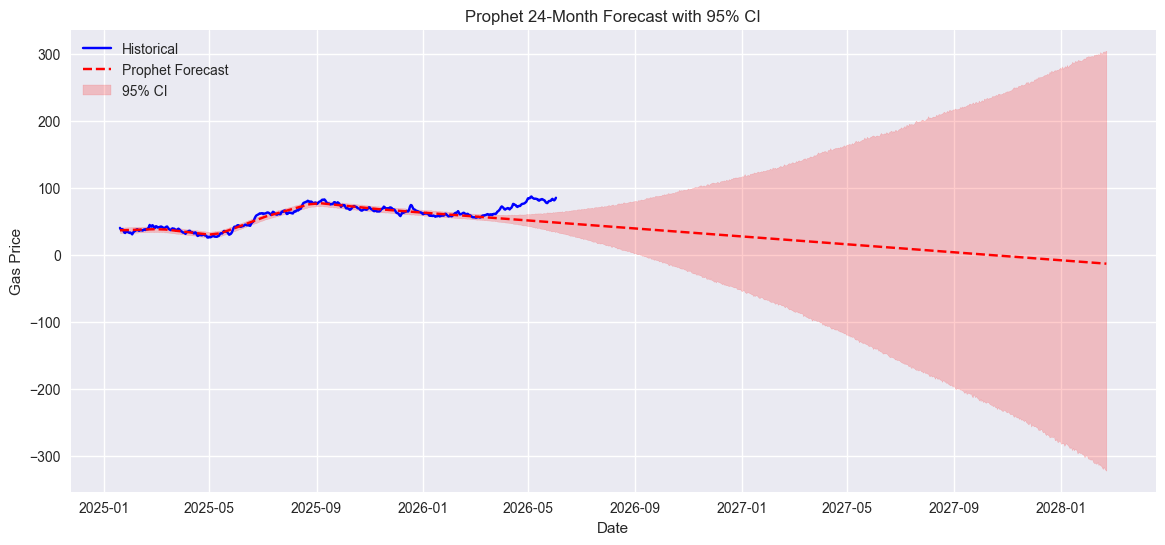

In [12]:
#full plot

def plot_future_forecast(prophet_df, forecast_df):
    plt.figure(figsize=(14,6))

    # Historical data
    plt.plot(prophet_df["ds"], prophet_df["y"], label="Historical", color="blue")

    # Forecast
    plt.plot(forecast_df["ds"], forecast_df["yhat"], label="Prophet Forecast", color="red", linestyle="--")

    # CI
    plt.fill_between(
        forecast_df["ds"],
        forecast_df["yhat_lower"],
        forecast_df["yhat_upper"],
        color="red",
        alpha=0.2,
        label="95% CI"
    )

    plt.title("Prophet 24-Month Forecast with 95% CI")
    plt.xlabel("Date")
    plt.ylabel("Gas Price")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_future_forecast(prophet_df, future_forecast)


In [13]:
#prophet HP tuning

def prophet_hp_tuning(train_df, test_df):
    cps_values = [0.01, 0.1, 0.5]          # changepoint_prior_scale
    sps_values = [1.0, 5.0, 10.0]          # seasonality_prior_scale

    results = []

    for cps in cps_values:
        for sps in sps_values:
            print(f"Testing cps={cps}, sps={sps}")

            model = Prophet(
                changepoint_prior_scale=cps,
                seasonality_prior_scale=sps,
                yearly_seasonality=False,
                weekly_seasonality=False,
                daily_seasonality=False
            )

            model.fit(train_df)

            future = model.make_future_dataframe(periods=len(test_df), freq="D")
            forecast = model.predict(future)

            pred = forecast["yhat"].iloc[-len(test_df):].values
            actual = test_df["y"].values

            rmse = np.sqrt(mean_squared_error(actual, pred))
            mae  = mean_absolute_error(actual, pred)

            results.append((cps, sps, rmse, mae))

    results_df = pd.DataFrame(results, columns=["cps", "sps", "RMSE", "MAE"])
    return results_df.sort_values("RMSE")

prophet_tuning_results = prophet_hp_tuning(train_df, test_df)
prophet_tuning_results


12:40:14 - cmdstanpy - INFO - Chain [1] start processing


Testing cps=0.01, sps=1.0


12:40:15 - cmdstanpy - INFO - Chain [1] done processing
12:40:15 - cmdstanpy - INFO - Chain [1] start processing


Testing cps=0.01, sps=5.0


12:40:16 - cmdstanpy - INFO - Chain [1] done processing
12:40:16 - cmdstanpy - INFO - Chain [1] start processing


...

Testing cps=0.5, sps=5.0


12:40:23 - cmdstanpy - INFO - Chain [1] done processing
12:40:23 - cmdstanpy - INFO - Chain [1] start processing


Testing cps=0.5, sps=10.0


12:40:24 - cmdstanpy - INFO - Chain [1] done processing


,cps,sps,RMSE,MAE
0,0.01,1.0,11.181025,9.892086
1,0.01,5.0,11.181025,9.892086
2,0.01,10.0,11.181025,9.892086
7,0.50,5.0,20.263961,16.653320
6,0.50,1.0,20.263961,16.653320
8,0.50,10.0,20.263961,16.653320
5,0.10,10.0,21.283004,17.541561
3,0.10,1.0,21.283004,17.541561
4,0.10,5.0,21.283004,17.541561


In [14]:
def prophet_predict_with_params(train_df, test_df, cps, sps):
    model = Prophet(
        changepoint_prior_scale=cps,
        seasonality_prior_scale=sps,
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(train_df)

    future = model.make_future_dataframe(periods=len(test_df), freq="D")
    forecast = model.predict(future)

    pred = forecast[["ds", "yhat"]].iloc[-len(test_df):].copy()
    pred["y_true"] = test_df["y"].values

    return pred


In [15]:
def plot_prophet_hp_results(pred_df, title):
    plt.figure(figsize=(12,5))
    plt.plot(pred_df["ds"], pred_df["y_true"], label="Actual", color="black")
    plt.plot(pred_df["ds"], pred_df["yhat"], label="Prophet Prediction", color="red")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.show()


12:40:25 - cmdstanpy - INFO - Chain [1] start processing
12:40:26 - cmdstanpy - INFO - Chain [1] done processing


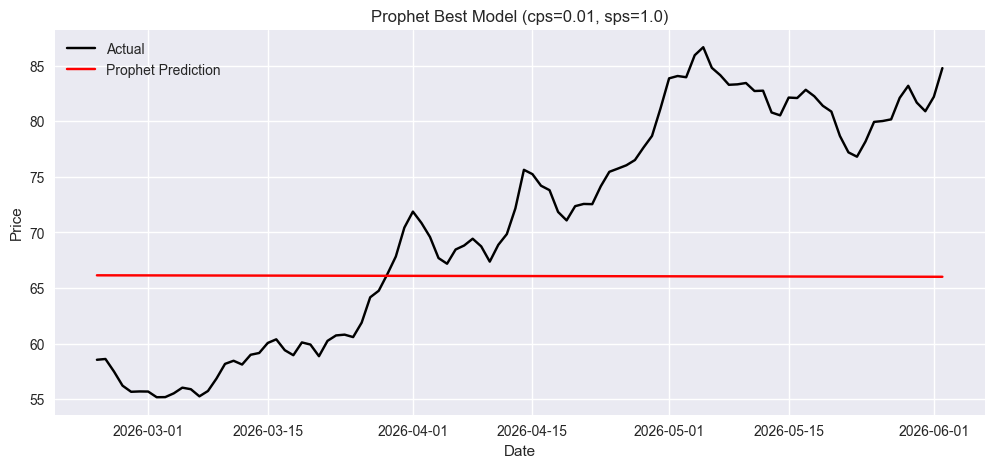

12:40:26 - cmdstanpy - INFO - Chain [1] start processing
12:40:27 - cmdstanpy - INFO - Chain [1] done processing


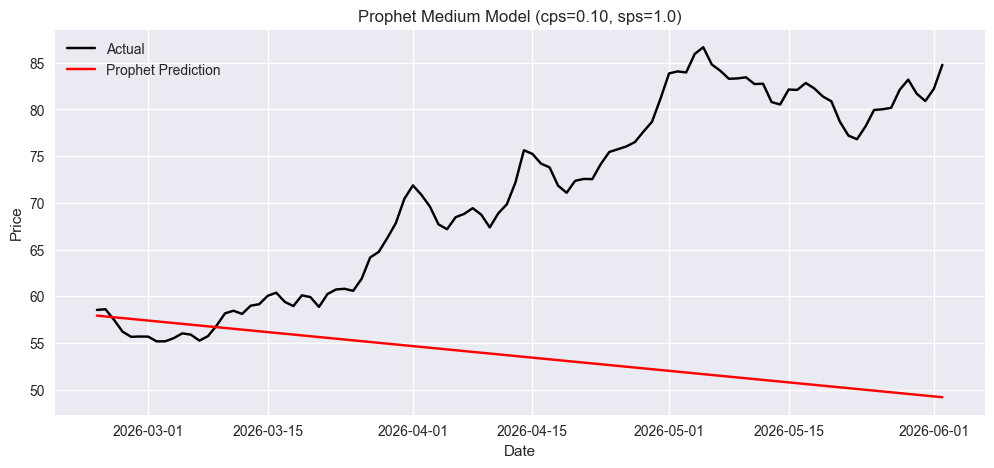

12:40:28 - cmdstanpy - INFO - Chain [1] start processing
12:40:29 - cmdstanpy - INFO - Chain [1] done processing


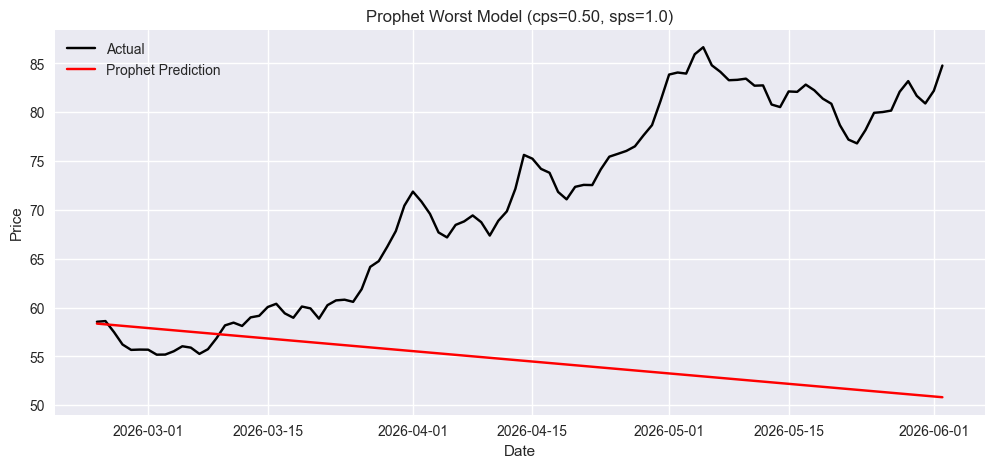

In [16]:
# Best model
best_pred = prophet_predict_with_params(train_df, test_df, cps=0.01, sps=1.0)
plot_prophet_hp_results(best_pred, "Prophet Best Model (cps=0.01, sps=1.0)")

# Medium model
mid_pred = prophet_predict_with_params(train_df, test_df, cps=0.10, sps=1.0)
plot_prophet_hp_results(mid_pred, "Prophet Medium Model (cps=0.10, sps=1.0)")

# Worst model
worst_pred = prophet_predict_with_params(train_df, test_df, cps=0.50, sps=1.0)
plot_prophet_hp_results(worst_pred, "Prophet Worst Model (cps=0.50, sps=1.0)")

In [17]:
best_prophet = Prophet(
    changepoint_prior_scale=0.01,
    seasonality_prior_scale=1.0,
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)

best_prophet.fit(train_df)


12:40:30 - cmdstanpy - INFO - Chain [1] start processing
12:40:30 - cmdstanpy - INFO - Chain [1] done processing


In [18]:
future_test = best_prophet.make_future_dataframe(periods=len(test_df), freq="D")
forecast_test = best_prophet.predict(future_test)

best_pred_test = forecast_test[["ds", "yhat"]].iloc[-len(test_df):].copy()
best_pred_test["y_true"] = test_df["y"].values


In [24]:
prophet_rmse = np.sqrt(mean_squared_error(best_pred_test["y_true"], best_pred_test["yhat"]))
prophet_mae  = mean_absolute_error(best_pred_test["y_true"], best_pred_test["yhat"])
prophet_mape = np.mean(np.abs((best_pred_test["y_true"] - best_pred_test["yhat"]) / best_pred_test["y_true"])) * 100

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MAPE: {mape:.2f}%")


RMSE: 11.1810
MAE:  9.8921
MAPE: 13.65%


In [25]:
import json

prophet_metrics = {
    "model": "Prophet",
    "rmse": float(prophet_rmse),
    "mae": float(prophet_mae),
    "mape": float(prophet_mape)
}

with open("../model_outputs/prophet_metrics.json", "w") as f:
    json.dump(prophet_metrics, f, indent=4)


In [20]:
best_prophet_full = Prophet(
    changepoint_prior_scale=0.01,
    seasonality_prior_scale=1.0,
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)

best_prophet_full.fit(prophet_df)


12:40:31 - cmdstanpy - INFO - Chain [1] start processing
12:40:32 - cmdstanpy - INFO - Chain [1] done processing


In [21]:
future_24m = best_prophet_full.make_future_dataframe(periods=730, freq="D")
forecast_24m = best_prophet_full.predict(future_24m)


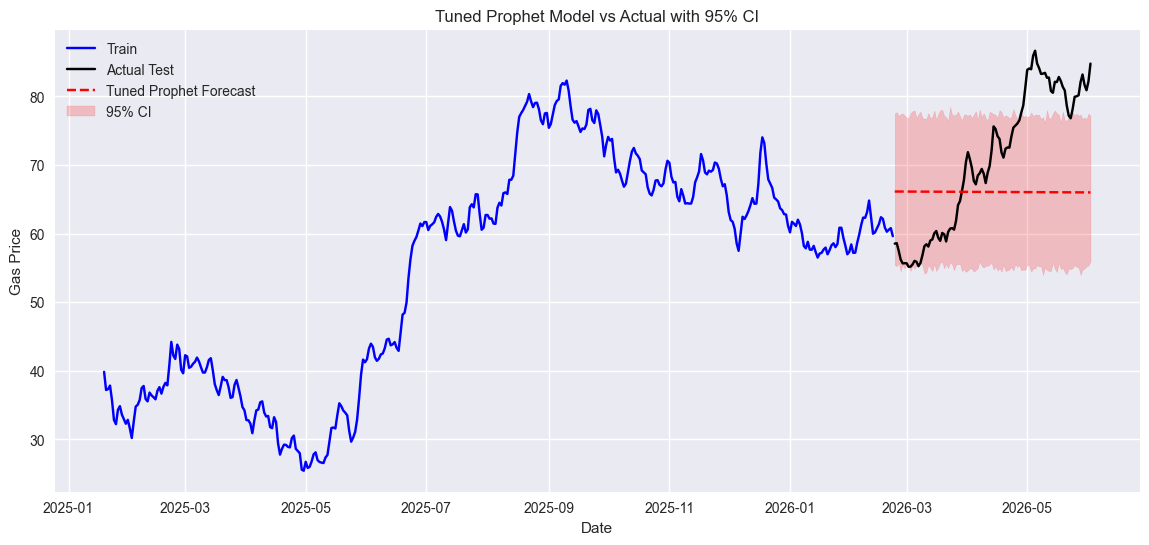

In [22]:
#test data prediction
plt.figure(figsize=(14,6))
plt.plot(train_df["ds"], train_df["y"], label="Train", color="blue")
plt.plot(test_df["ds"], test_df["y"], label="Actual Test", color="black")
test_forecast = forecast_test.iloc[-len(test_df):]

plt.plot(
    test_forecast["ds"],
    test_forecast["yhat"],
    label="Tuned Prophet Forecast",
    color="red",
    linestyle="--"
)

plt.fill_between(
    test_forecast["ds"],
    test_forecast["yhat_lower"],
    test_forecast["yhat_upper"],
    color="red",
    alpha=0.2,
    label="95% CI"
)

plt.title("Tuned Prophet Model vs Actual with 95% CI")
plt.xlabel("Date")
plt.ylabel("Gas Price")
plt.legend()
plt.grid(True)
plt.show()


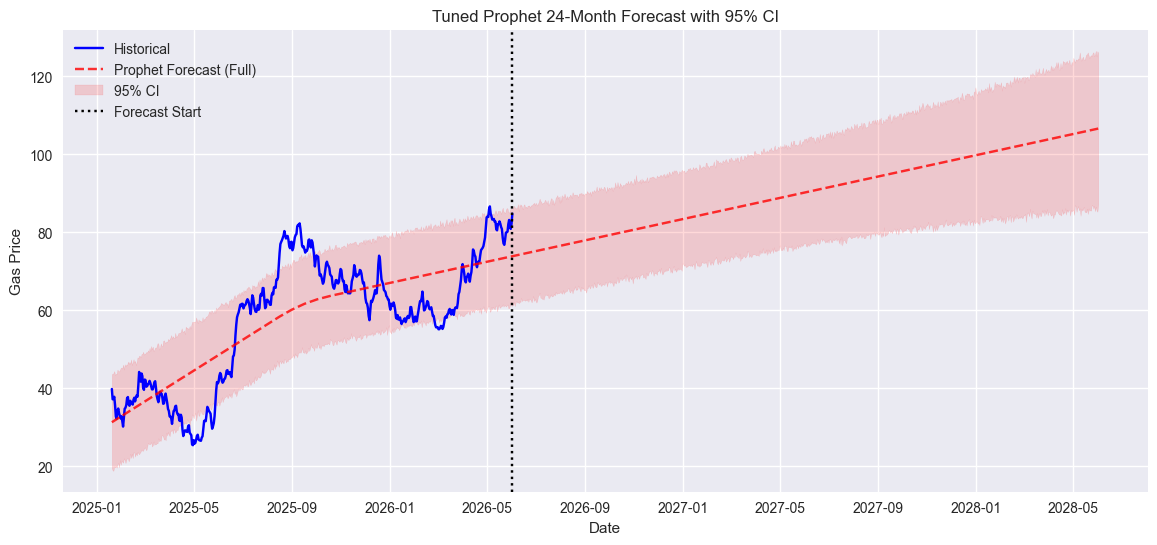

In [23]:
#tuned 24 month forecast
plt.figure(figsize=(14,6))

plt.plot(prophet_df["ds"], prophet_df["y"], label="Historical", color="blue")

plt.plot(
    forecast_24m["ds"],
    forecast_24m["yhat"],
    label="Prophet Forecast (Full)",
    color="red",
    linestyle="--",
    alpha=0.8
)

plt.fill_between(
    forecast_24m["ds"],
    forecast_24m["yhat_lower"],
    forecast_24m["yhat_upper"],
    color="red",
    alpha=0.15,
    label="95% CI"
)

last_date = prophet_df["ds"].max()
plt.axvline(last_date, color="black", linestyle=":", label="Forecast Start")

plt.title("Tuned Prophet 24-Month Forecast with 95% CI")
plt.xlabel("Date")
plt.ylabel("Gas Price")
plt.legend()
plt.grid(True)
plt.show()
